# Phase 5, Notebook 02: Multi-task Prediction Heads for VGGT

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChunLI-666/3DGS-from-scratch/blob/develop/notebooks/phase5/02_multitask_heads.ipynb)

## Learning Objectives

By the end of this notebook, you will:
- Understand the **4 specialized output heads** in VGGT architecture
- Learn the **Camera Head** architecture with iterative refinement
- Explore **rotation representations** (Euler, quaternions, 6D) and their trade-offs
- Understand the **DPT (Dense Prediction Transformer)** depth head
- Learn about the **Track Head** based on CoTracker

## Estimated Time

**55 minutes**

## Prerequisites

- **Phase 5, Notebook 00**: VGGT Overview
- **Phase 5, Notebook 01**: Token Aggregation

In [1]:
# 环境设置 - Environment Setup
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import torch
import torch.nn as nn
import torch.nn.functional as F

# 设置随机种子以保证可重复性
np.random.seed(42)
torch.manual_seed(42)

print("Environment setup complete!")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Environment setup complete!
PyTorch version: 2.10.0+cu128
Device: cpu


/home/user/miniconda3/lib/python3.11/site-packages/torch/cuda/__init__.py:184: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


## Section 1: Overview of VGGT's 4 Output Heads

VGGT follows a **shared backbone → specialized heads** pattern, which is common in multi-task learning:

```
DINOv2 Encoder → Token Aggregator → [Camera Head, Depth Head, Point Head, Track Head]
```

### The Four Heads

1. **Camera Head**
   - **Input**: Camera tokens `[B, S, C]`
   - **Output**: Camera poses (rotation + translation) + intrinsics (FoV)
   - **Architecture**: 4-layer Transformer with iterative refinement

2. **Depth Head** (DPT-based)
   - **Input**: Multi-scale image tokens from layers [4, 11, 17, 23]
   - **Output**: Depth maps `[B, S, H, W]` + confidence maps
   - **Architecture**: Dense Prediction Transformer (DPT)

3. **Point Head** (DPT-based)
   - **Input**: Same multi-scale tokens as Depth Head
   - **Output**: 3D point maps `[B, S, H, W, 3]` + confidence
   - **Architecture**: DPT with 4-channel output (xyz + conf)
   - **Note**: In practice, depth unprojection is preferred over direct point prediction

4. **Track Head** (CoTracker-based)
   - **Input**: Image tokens + query points
   - **Output**: 2D tracks `[B, S, N_q, 2]` + visibility + confidence
   - **Architecture**: DPT feature extractor + CoTracker tracker with correlation + GRU

### Why Specialized Heads?

- **Different output spaces**: Poses (SE(3)), depths (R+), tracks (R²)
- **Different resolutions**: Camera (per-frame), Depth/Point (per-pixel), Tracks (per-query)
- **Task-specific inductive biases**: E.g., iterative refinement for poses, multi-scale fusion for dense prediction

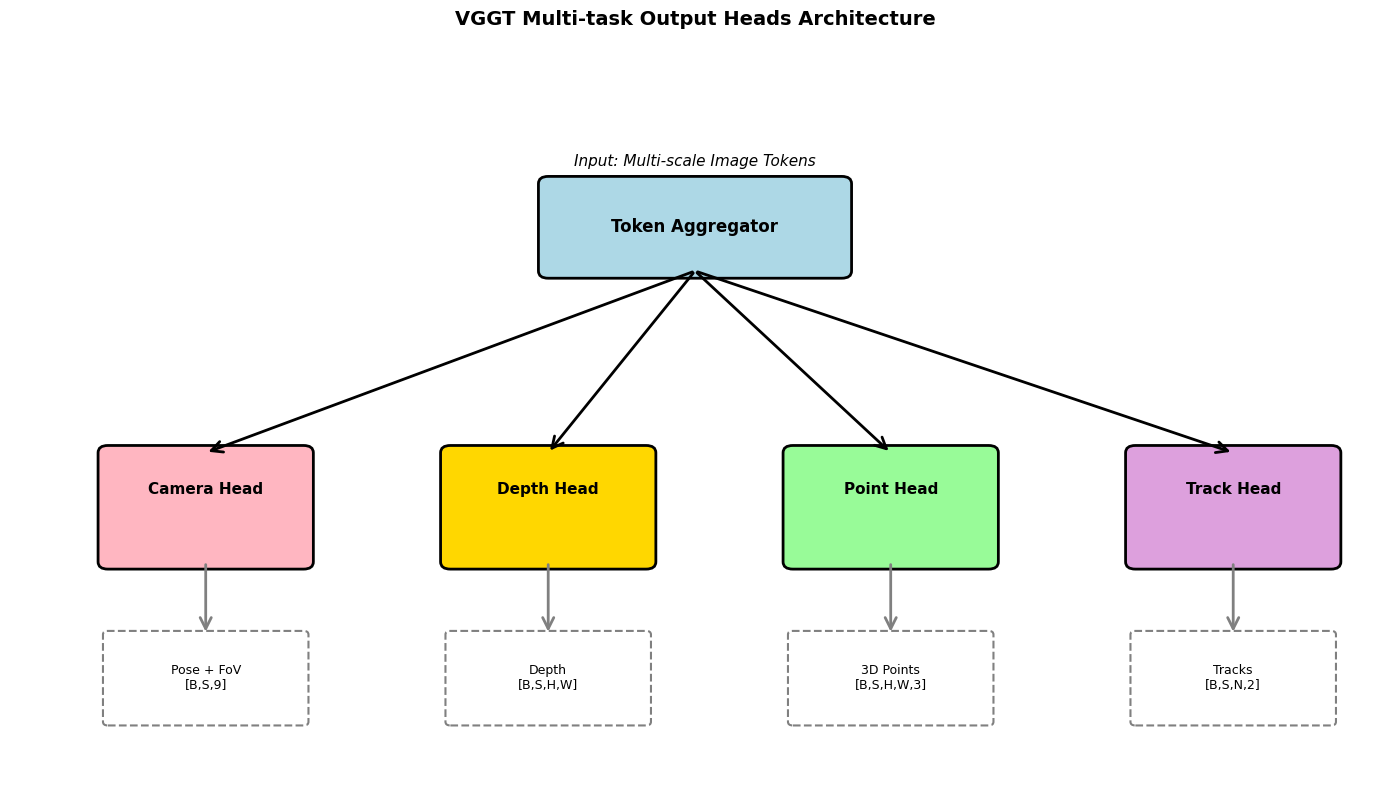


4个输出头总结:
1. Camera Head: 相机位姿和内参估计
2. Depth Head: 稠密深度预测 (DPT)
3. Point Head: 直接3D点预测 (实践中较少使用)
4. Track Head: 2D点轨迹跟踪 (基于CoTracker)


In [2]:
# 架构图 - Architecture Diagram
# 可视化VGGT的4个输出头

fig, ax = plt.subplots(1, 1, figsize=(14, 8))
ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis('off')

# 共享聚合器 - Shared Aggregator
aggregator = FancyBboxPatch((5.5, 7), 3, 1.2, 
                            boxstyle="round,pad=0.1", 
                            edgecolor='black', 
                            facecolor='lightblue', 
                            linewidth=2)
ax.add_patch(aggregator)
ax.text(7, 7.6, 'Token Aggregator', ha='center', va='center', 
        fontsize=12, fontweight='bold')

# 4个输出头的位置和颜色
heads = [
    {'name': 'Camera Head', 'x': 1, 'color': '#FFB6C1', 'output': 'Pose + FoV\n[B,S,9]'},
    {'name': 'Depth Head', 'x': 4.5, 'color': '#FFD700', 'output': 'Depth\n[B,S,H,W]'},
    {'name': 'Point Head', 'x': 8, 'color': '#98FB98', 'output': '3D Points\n[B,S,H,W,3]'},
    {'name': 'Track Head', 'x': 11.5, 'color': '#DDA0DD', 'output': 'Tracks\n[B,S,N,2]'},
]

# 绘制4个头
for head in heads:
    # 头部框
    box = FancyBboxPatch((head['x'], 3), 2, 1.5, 
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', 
                         facecolor=head['color'], 
                         linewidth=2)
    ax.add_patch(box)
    ax.text(head['x'] + 1, 4, head['name'], ha='center', va='center', 
            fontsize=11, fontweight='bold')
    
    # 输出框
    out_box = FancyBboxPatch((head['x'], 0.8), 2, 1.2, 
                             boxstyle="round,pad=0.05", 
                             edgecolor='gray', 
                             facecolor='white', 
                             linewidth=1.5,
                             linestyle='--')
    ax.add_patch(out_box)
    ax.text(head['x'] + 1, 1.4, head['output'], ha='center', va='center', 
            fontsize=9)
    
    # 从聚合器到头的箭头
    arrow1 = FancyArrowPatch((7, 7), (head['x'] + 1, 4.5),
                            arrowstyle='->', mutation_scale=20, 
                            linewidth=2, color='black')
    ax.add_patch(arrow1)
    
    # 从头到输出的箭头
    arrow2 = FancyArrowPatch((head['x'] + 1, 3), (head['x'] + 1, 2),
                            arrowstyle='->', mutation_scale=20, 
                            linewidth=2, color='gray')
    ax.add_patch(arrow2)

# 添加输入标签
ax.text(7, 8.5, 'Input: Multi-scale Image Tokens', ha='center', va='center', 
        fontsize=11, style='italic')

plt.title('VGGT Multi-task Output Heads Architecture', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n4个输出头总结:")
print("1. Camera Head: 相机位姿和内参估计")
print("2. Depth Head: 稠密深度预测 (DPT)")
print("3. Point Head: 直接3D点预测 (实践中较少使用)")
print("4. Track Head: 2D点轨迹跟踪 (基于CoTracker)")

## Section 2: Camera Head - Pose and Intrinsics Estimation

The Camera Head predicts both **extrinsic** (pose) and **intrinsic** (field of view) parameters for each camera.

### Architecture

```python
CameraToken [B,S,2048] → 4-layer Transformer → Linear → pose_encoding [B,S,9]
```

### Iterative Refinement (4 iterations)

The Camera Head uses **iterative refinement** to gradually improve pose estimates:

```
Iteration 1: Initial pose estimate
Iteration 2: Refine based on iteration 1
Iteration 3: Refine based on iteration 2
Iteration 4: Final refined pose
```

### Pose Encoding Format

The output `pose_encoding` has shape `[B, S, 9]` with:
- **absT** (3): Absolute translation in world coordinates
- **quaR** (4): Rotation as quaternion (w, x, y, z)
- **FoV** (2): Field of view (horizontal, vertical) in degrees

### Conversion to Camera Parameters

The function `pose_encoding_to_extri_intri()` converts this encoding to:
- **Extrinsics**: 4×4 transformation matrix [R|t]
- **Intrinsics**: Focal lengths (fx, fy) and principal point (cx, cy)

演示相机头的迭代优化过程



输入形状: torch.Size([2, 3, 2048])
输出形状: torch.Size([4, 2, 3, 9])
  - 4次迭代, 每次输出 [B=2, S=3, 9]


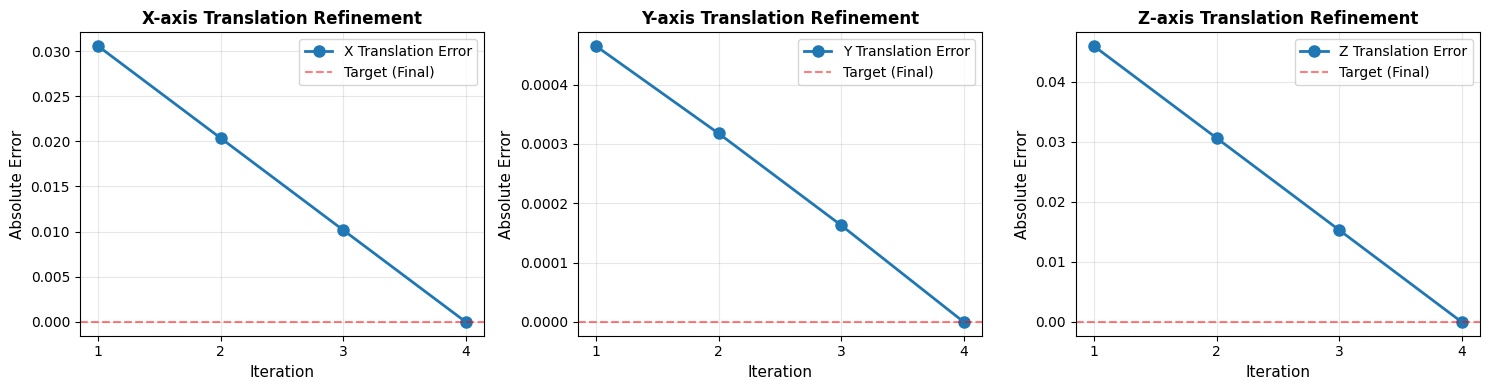


迭代优化的优势:
  1. 逐步接近最优解,避免大幅跳跃
  2. 可以在中间迭代进行监督训练
  3. 类似于优化算法中的梯度下降
  4. 对噪声输入更鲁棒


In [3]:
# 简化的相机头实现 - Simplified Camera Head Implementation

class SimplifiedCameraHead(nn.Module):
    """简化版相机头,展示迭代优化概念"""
    
    def __init__(self, dim_in=2048, num_iterations=4):
        super().__init__()
        self.num_iterations = num_iterations
        
        # 简化版:每次迭代使用相同的MLP
        # 实际VGGT使用4层Transformer
        self.refine_mlp = nn.Sequential(
            nn.Linear(dim_in + 9, 512),  # +9 for previous pose encoding
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 9)  # Output: 3(trans) + 4(quat) + 2(fov)
        )
        
        # 初始化预测
        self.initial_mlp = nn.Sequential(
            nn.Linear(dim_in, 512),
            nn.ReLU(),
            nn.Linear(512, 9)
        )
    
    def forward(self, camera_tokens):
        """
        Args:
            camera_tokens: [B, S, dim_in] - 相机特征tokens
        Returns:
            pose_encodings: [num_iterations, B, S, 9] - 每次迭代的位姿编码
        """
        B, S, _ = camera_tokens.shape
        
        # 存储每次迭代的结果
        all_poses = []
        
        # 第一次迭代: 初始预测
        pose = self.initial_mlp(camera_tokens)  # [B, S, 9]
        all_poses.append(pose)
        
        # 后续迭代: 基于前一次结果优化
        for i in range(1, self.num_iterations):
            # 拼接当前特征和前一次的位姿编码
            combined = torch.cat([camera_tokens, pose], dim=-1)  # [B, S, dim_in+9]
            
            # 预测残差并更新
            residual = self.refine_mlp(combined)
            pose = pose + 0.1 * residual  # 小步长更新
            all_poses.append(pose)
        
        return torch.stack(all_poses, dim=0)  # [num_iterations, B, S, 9]


# 演示迭代优化过程
print("=" * 60)
print("演示相机头的迭代优化过程")
print("=" * 60)

# 创建模型和模拟输入
camera_head = SimplifiedCameraHead(dim_in=2048, num_iterations=4)
camera_head.eval()

# 模拟输入: 2个batch, 3帧
B, S = 2, 3
camera_tokens = torch.randn(B, S, 2048)

with torch.no_grad():
    pose_encodings = camera_head(camera_tokens)  # [4, 2, 3, 9]

print(f"\n输入形状: {camera_tokens.shape}")
print(f"输出形状: {pose_encodings.shape}")
print(f"  - 4次迭代, 每次输出 [B={B}, S={S}, 9]")

# 可视化迭代优化效果
# 我们观察平移分量的变化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for axis_idx, axis_name in enumerate(['X', 'Y', 'Z']):
    ax = axes[axis_idx]
    
    # 提取该轴的平移分量
    trans_values = pose_encodings[:, 0, 0, axis_idx].numpy()  # [4] - 4次迭代
    
    # 设置"ground truth"为最后一次迭代的值
    gt_value = trans_values[-1]
    
    # 计算误差
    errors = np.abs(trans_values - gt_value)
    
    # 绘制误差随迭代次数的变化
    iterations = np.arange(1, 5)
    ax.plot(iterations, errors, 'o-', linewidth=2, markersize=8, label=f'{axis_name} Translation Error')
    ax.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='Target (Final)')
    ax.set_xlabel('Iteration', fontsize=11)
    ax.set_ylabel('Absolute Error', fontsize=11)
    ax.set_title(f'{axis_name}-axis Translation Refinement', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    ax.set_xticks(iterations)

plt.tight_layout()
plt.show()

print("\n迭代优化的优势:")
print("  1. 逐步接近最优解,避免大幅跳跃")
print("  2. 可以在中间迭代进行监督训练")
print("  3. 类似于优化算法中的梯度下降")
print("  4. 对噪声输入更鲁棒")

## Section 3: Rotation Representations

Representing 3D rotations is non-trivial. Different representations have different trade-offs.

### Common Rotation Representations

| Representation | Parameters | Pros | Cons |
|----------------|------------|------|------|
| **Euler Angles** | 3 (roll, pitch, yaw) | Intuitive, minimal | Gimbal lock, discontinuous |
| **Rotation Matrix** | 9 (3×3 matrix) | Direct, no singularities | Redundant, needs orthogonality constraint |
| **Quaternion** | 4 (w, x, y, z) | Compact, continuous, no gimbal lock | Non-intuitive, needs normalization |
| **6D Representation** | 6 (two 3D vectors) | Continuous, no normalization needed | Slightly redundant |

### Why VGGT Uses Quaternions

VGGT chooses **quaternions** because:
1. **Compact**: Only 4 parameters (vs 9 for rotation matrix)
2. **Continuous**: Smooth in parameter space (vs Euler angles)
3. **No gimbal lock**: Unlike Euler angles
4. **Easy to normalize**: Just divide by L2 norm
5. **Efficient composition**: Quaternion multiplication is fast

### Quaternion Format

A quaternion q = (w, x, y, z) represents a rotation where:
- **w**: Scalar part (cos(θ/2))
- **(x, y, z)**: Vector part (sin(θ/2) * axis)

Constraint: w² + x² + y² + z² = 1

### Conversion to Rotation Matrix

```python
R = [[1-2(y²+z²),   2(xy-wz),   2(xz+wy)],
     [  2(xy+wz), 1-2(x²+z²),   2(yz-wx)],
     [  2(xz-wy),   2(yz+wx), 1-2(x²+y²)]]
```

演示不同旋转表示的连续性


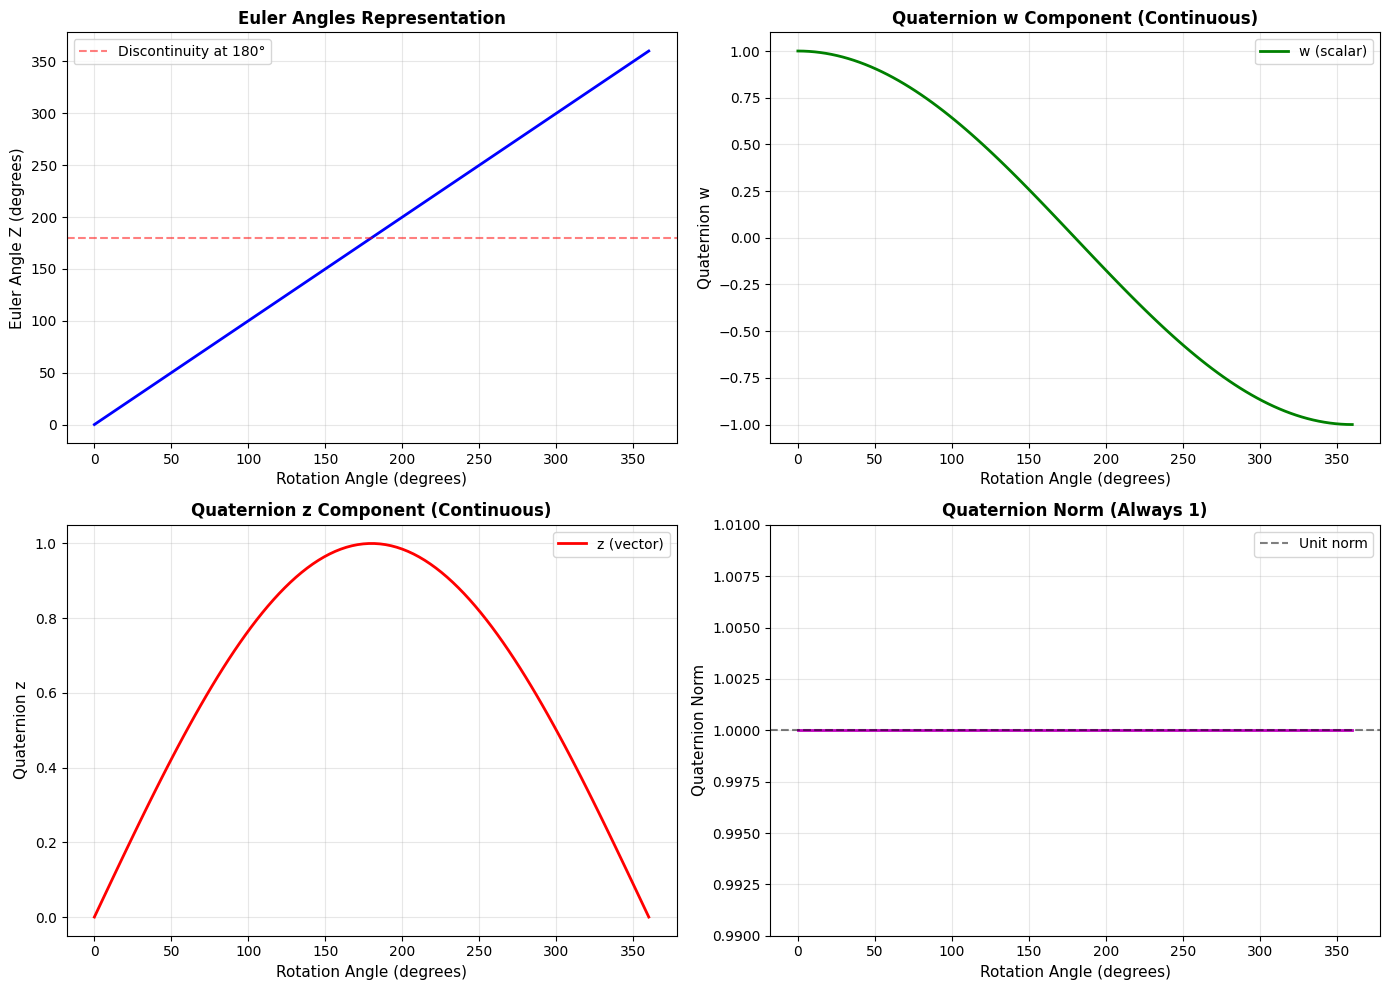


测试四元数 ↔ 旋转矩阵转换:
输入四元数形状: torch.Size([2, 4])
输出旋转矩阵形状: torch.Size([2, 3, 3])

第一个旋转矩阵 (无旋转, 应该是单位矩阵):
tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

第二个旋转矩阵 (绕Z轴90度):
tensor([[ 5.9605e-08, -1.0000e+00,  0.0000e+00],
        [ 1.0000e+00,  5.9605e-08,  0.0000e+00],
        [ 0.0000e+00,  0.0000e+00,  1.0000e+00]])

四元数表示的优势:
  ✓ 参数空间连续,适合神经网络优化
  ✓ 没有万向节死锁问题
  ✓ 仅需4个参数 (vs 旋转矩阵的9个)
  ✓ 归一化简单 (除以L2范数)


In [4]:
# 四元数到旋转矩阵的转换 - Quaternion to Rotation Matrix

def quaternion_to_rotation_matrix(q):
    """
    将四元数转换为旋转矩阵
    
    Args:
        q: [..., 4] - 四元数 (w, x, y, z)
    Returns:
        R: [..., 3, 3] - 旋转矩阵
    """
    # 归一化四元数
    q = q / torch.norm(q, dim=-1, keepdim=True)
    
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]
    
    # 计算旋转矩阵的9个元素
    R = torch.stack([
        torch.stack([1 - 2*(y*y + z*z),     2*(x*y - w*z),     2*(x*z + w*y)], dim=-1),
        torch.stack([    2*(x*y + w*z), 1 - 2*(x*x + z*z),     2*(y*z - w*x)], dim=-1),
        torch.stack([    2*(x*z - w*y),     2*(y*z + w*x), 1 - 2*(x*x + y*y)], dim=-1),
    ], dim=-2)
    
    return R


def rotation_matrix_to_quaternion(R):
    """
    将旋转矩阵转换为四元数 (用于演示)
    
    Args:
        R: [..., 3, 3] - 旋转矩阵
    Returns:
        q: [..., 4] - 四元数 (w, x, y, z)
    """
    trace = R[..., 0, 0] + R[..., 1, 1] + R[..., 2, 2]
    
    w = torch.sqrt(1.0 + trace) / 2.0
    x = (R[..., 2, 1] - R[..., 1, 2]) / (4.0 * w)
    y = (R[..., 0, 2] - R[..., 2, 0]) / (4.0 * w)
    z = (R[..., 1, 0] - R[..., 0, 1]) / (4.0 * w)
    
    return torch.stack([w, x, y, z], dim=-1)


# 演示四元数表示的连续性
print("=" * 60)
print("演示不同旋转表示的连续性")
print("=" * 60)

# 创建一系列绕Z轴的旋转
angles = np.linspace(0, 2*np.pi, 100)  # 0到360度

# 欧拉角表示 (会有不连续性)
euler_angles = angles

# 四元数表示
quaternions = []
for angle in angles:
    # 绕Z轴旋转的四元数: (cos(θ/2), 0, 0, sin(θ/2))
    w = np.cos(angle / 2)
    x = 0.0
    y = 0.0
    z = np.sin(angle / 2)
    quaternions.append([w, x, y, z])
quaternions = np.array(quaternions)

# 可视化连续性
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 欧拉角
axes[0, 0].plot(np.degrees(angles), np.degrees(euler_angles), 'b-', linewidth=2)
axes[0, 0].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[0, 0].set_ylabel('Euler Angle Z (degrees)', fontsize=11)
axes[0, 0].set_title('Euler Angles Representation', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].axhline(y=180, color='r', linestyle='--', alpha=0.5, label='Discontinuity at 180°')
axes[0, 0].legend()

# 四元数 - w分量
axes[0, 1].plot(np.degrees(angles), quaternions[:, 0], 'g-', linewidth=2, label='w (scalar)')
axes[0, 1].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[0, 1].set_ylabel('Quaternion w', fontsize=11)
axes[0, 1].set_title('Quaternion w Component (Continuous)', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 四元数 - z分量
axes[1, 0].plot(np.degrees(angles), quaternions[:, 3], 'r-', linewidth=2, label='z (vector)')
axes[1, 0].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[1, 0].set_ylabel('Quaternion z', fontsize=11)
axes[1, 0].set_title('Quaternion z Component (Continuous)', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 四元数范数 (应该恒为1)
quat_norms = np.linalg.norm(quaternions, axis=1)
axes[1, 1].plot(np.degrees(angles), quat_norms, 'm-', linewidth=2)
axes[1, 1].set_xlabel('Rotation Angle (degrees)', fontsize=11)
axes[1, 1].set_ylabel('Quaternion Norm', fontsize=11)
axes[1, 1].set_title('Quaternion Norm (Always 1)', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Unit norm')
axes[1, 1].legend()
axes[1, 1].set_ylim([0.99, 1.01])

plt.tight_layout()
plt.show()

# 测试转换函数
print("\n测试四元数 ↔ 旋转矩阵转换:")
q_test = torch.tensor([[1.0, 0.0, 0.0, 0.0],  # 无旋转
                       [0.707, 0.0, 0.0, 0.707]])  # 绕Z轴90度
R_test = quaternion_to_rotation_matrix(q_test)
print(f"输入四元数形状: {q_test.shape}")
print(f"输出旋转矩阵形状: {R_test.shape}")
print(f"\n第一个旋转矩阵 (无旋转, 应该是单位矩阵):")
print(R_test[0])
print(f"\n第二个旋转矩阵 (绕Z轴90度):")
print(R_test[1])

print("\n四元数表示的优势:")
print("  ✓ 参数空间连续,适合神经网络优化")
print("  ✓ 没有万向节死锁问题")
print("  ✓ 仅需4个参数 (vs 旋转矩阵的9个)")
print("  ✓ 归一化简单 (除以L2范数)")

## Section 4: Depth Head (DPT Architecture)

The Depth Head uses the **DPT (Dense Prediction Transformer)** architecture, originally from [Ranftl et al., ICCV 2021](https://arxiv.org/abs/2103.13413).

### Architecture Overview

```
Multi-scale Image Tokens (layers 4,11,17,23) → Reassemble → Fusion → Output Head
```

### Multi-scale Features

DPT extracts features from 4 layers of the DINOv2 backbone:
- **Layer 4**: Early features (fine details)
- **Layer 11**: Mid-level features
- **Layer 17**: High-level features
- **Layer 23**: Final features (semantic)

### Reassemble Operation

Each layer's tokens are "reassembled" into 2D feature maps:
1. **Reshape**: `[B, N, C]` → `[B, H, W, C]` where N = H×W
2. **Project**: Linear projection to target dimension
3. **Upsample**: Bilinear upsampling to output resolution

### Fusion Module

The 4 reassembled feature maps are **fused** hierarchically:
- Features are combined from coarse to fine
- Each fusion step uses residual refinement
- Final fused feature has highest spatial resolution

### Output Head

```python
fused_features → Conv2d → Activation → depth_map + confidence_map
```

**Activations**:
- Depth: `exp` activation (ensures positive values)
- Confidence: `expp1` activation (exp + 1, ensures ≥ 1)

### Output Shape

- **Depth**: `[B, S, H, W]` - per-pixel depth
- **Confidence**: `[B, S, H, W]` - per-pixel confidence

演示DPT深度头的多尺度特征融合

输入多尺度特征:
  Layer  4: torch.Size([2, 256, 64, 64])
  Layer 11: torch.Size([2, 512, 32, 32])
  Layer 17: torch.Size([2, 1024, 16, 16])
  Layer 23: torch.Size([2, 2048, 8, 8])



输出:
  Depth:      torch.Size([2, 1, 64, 64])
  Confidence: torch.Size([2, 1, 64, 64])

深度值范围: [0.846, 1.454]
置信度范围: [1.760, 2.328]


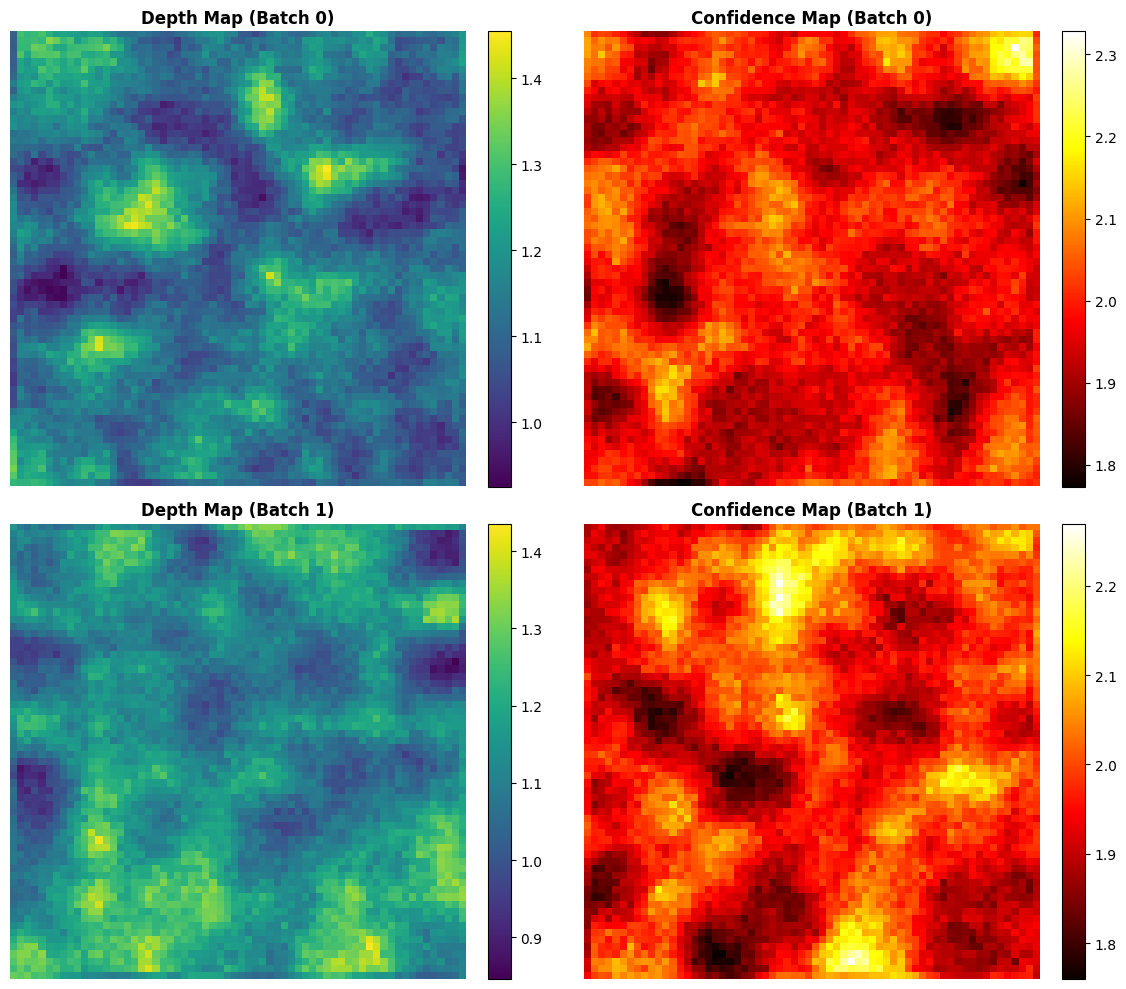


DPT深度头的关键特性:
  1. 多尺度特征提取: 从不同层获取不同粒度的信息
  2. 特征重组: 将token序列还原为2D特征图
  3. 层级融合: 自顶向下逐步融合特征
  4. 激活函数: exp确保深度为正, expp1确保置信度≥1


In [5]:
# 简化的DPT深度头实现 - Simplified DPT Depth Head

class SimplifiedDPTDepthHead(nn.Module):
    """简化版DPT深度头,展示多尺度特征融合"""
    
    def __init__(self, feature_dims=[256, 512, 1024, 2048], output_dim=2):
        super().__init__()
        self.feature_dims = feature_dims
        
        # Reassemble: 将每个层的特征投影到统一维度
        target_dim = 256
        self.reassemble_layers = nn.ModuleList([
            nn.Conv2d(dim, target_dim, kernel_size=1) for dim in feature_dims
        ])
        
        # Fusion: 自底向上融合特征
        self.fusion_layers = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(target_dim * 2, target_dim, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(target_dim, target_dim, kernel_size=3, padding=1),
            ) for _ in range(3)  # 3次融合
        ])
        
        # Output head: 深度 + 置信度
        self.output_head = nn.Sequential(
            nn.Conv2d(target_dim, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, output_dim, kernel_size=1)  # 2 channels: depth + conf
        )
    
    def forward(self, multi_scale_features):
        """
        Args:
            multi_scale_features: List of 4 feature maps from layers [4,11,17,23]
                Each has shape [B, C_i, H_i, W_i]
        Returns:
            depth: [B, 1, H, W]
            confidence: [B, 1, H, W]
        """
        # Step 1: Reassemble - 投影到统一维度并上采样
        target_size = multi_scale_features[0].shape[-2:]  # 使用最高分辨率
        reassembled = []
        
        for i, feat in enumerate(multi_scale_features):
            # 投影到目标维度
            feat_proj = self.reassemble_layers[i](feat)
            # 上采样到目标分辨率
            feat_up = F.interpolate(feat_proj, size=target_size, 
                                   mode='bilinear', align_corners=False)
            reassembled.append(feat_up)
        
        # Step 2: Fusion - 自底向上融合
        # 从最粗糙的特征开始 (layer 23)
        fused = reassembled[-1]
        
        for i in range(len(reassembled) - 2, -1, -1):
            # 拼接当前融合结果和更精细的特征
            combined = torch.cat([fused, reassembled[i]], dim=1)
            # 通过融合层
            fused = self.fusion_layers[i](combined) + fused  # 残差连接
        
        # Step 3: Output head
        output = self.output_head(fused)  # [B, 2, H, W]
        
        # 分离深度和置信度,并应用激活函数
        depth = torch.exp(output[:, 0:1, :, :])  # exp for positive depth
        confidence = torch.exp(output[:, 1:2, :, :]) + 1.0  # expp1 for conf >= 1
        
        return depth, confidence


# 演示DPT深度头
print("=" * 60)
print("演示DPT深度头的多尺度特征融合")
print("=" * 60)

# 创建模型
depth_head = SimplifiedDPTDepthHead()
depth_head.eval()

# 创建模拟的多尺度特征
B = 2
H, W = 64, 64  # 输出分辨率

multi_scale_features = [
    torch.randn(B, 256, H, W),      # Layer 4 - 最精细
    torch.randn(B, 512, H//2, W//2),    # Layer 11
    torch.randn(B, 1024, H//4, W//4),   # Layer 17
    torch.randn(B, 2048, H//8, W//8),   # Layer 23 - 最粗糙
]

print("\n输入多尺度特征:")
for i, feat in enumerate(multi_scale_features):
    layer_num = [4, 11, 17, 23][i]
    print(f"  Layer {layer_num:2d}: {feat.shape}")

# 前向传播
with torch.no_grad():
    depth, confidence = depth_head(multi_scale_features)

print(f"\n输出:")
print(f"  Depth:      {depth.shape}")
print(f"  Confidence: {confidence.shape}")
print(f"\n深度值范围: [{depth.min():.3f}, {depth.max():.3f}]")
print(f"置信度范围: [{confidence.min():.3f}, {confidence.max():.3f}]")

# 可视化深度和置信度
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 显示两个batch的深度和置信度
for b in range(2):
    # 深度图
    im1 = axes[b, 0].imshow(depth[b, 0].numpy(), cmap='viridis')
    axes[b, 0].set_title(f'Depth Map (Batch {b})', fontsize=12, fontweight='bold')
    axes[b, 0].axis('off')
    plt.colorbar(im1, ax=axes[b, 0], fraction=0.046, pad=0.04)
    
    # 置信度图
    im2 = axes[b, 1].imshow(confidence[b, 0].numpy(), cmap='hot')
    axes[b, 1].set_title(f'Confidence Map (Batch {b})', fontsize=12, fontweight='bold')
    axes[b, 1].axis('off')
    plt.colorbar(im2, ax=axes[b, 1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\nDPT深度头的关键特性:")
print("  1. 多尺度特征提取: 从不同层获取不同粒度的信息")
print("  2. 特征重组: 将token序列还原为2D特征图")
print("  3. 层级融合: 自顶向下逐步融合特征")
print("  4. 激活函数: exp确保深度为正, expp1确保置信度≥1")

## Section 5: Point Head - Direct 3D Point Prediction

The Point Head shares the same DPT architecture as the Depth Head, but outputs **3D world coordinates** directly.

### Architecture

```
Multi-scale Tokens → DPT → point_map [B,S,H,W,3] + confidence [B,S,H,W,1]
```

### Output Format

- **Point Map**: `[B, S, H, W, 3]` - (x, y, z) in world coordinates
- **Confidence**: `[B, S, H, W, 1]` - per-pixel confidence

### Activation Function

The Point Head uses **`inv_log`** activation:
```python
inv_log(x) = sign(x) * log(1 + abs(x))
```

This provides:
- Unbounded output (can be positive or negative)
- Compressed dynamic range for large values
- Smooth gradients

### Why Depth Unprojection is Preferred

In practice, **depth + camera unprojection** is better than direct point prediction:

1. **Depth is relative**: Easier to learn depth relationships than absolute 3D positions
2. **Camera geometry**: Leverages known camera intrinsics for unprojection
3. **Consistency**: Ensures points lie on valid camera rays
4. **Less ambiguity**: Multiple 3D points can project to same 2D location

### Unprojection Formula

Given depth d, pixel (u, v), and intrinsics K:
```
x = (u - cx) * d / fx
y = (v - cy) * d / fy
z = d
```
where (fx, fy) are focal lengths and (cx, cy) is the principal point.

深度反投影 vs 直接3D点预测

深度图形状: torch.Size([2, 1, 32, 32])
内参形状: torch.Size([2, 4])
反投影点图形状: torch.Size([2, 3, 32, 32])
直接预测点图形状: torch.Size([2, 3, 32, 32])

方法1: 深度反投影
  X范围: [-2.062, 1.896]
  Y范围: [-1.975, 1.863]
  Z范围: [3.036, 6.742]

方法2: 直接点预测 (with inv_log)
  X范围: [-2.115, 2.076]
  Y范围: [-2.194, 1.996]
  Z范围: [-2.219, 2.024]


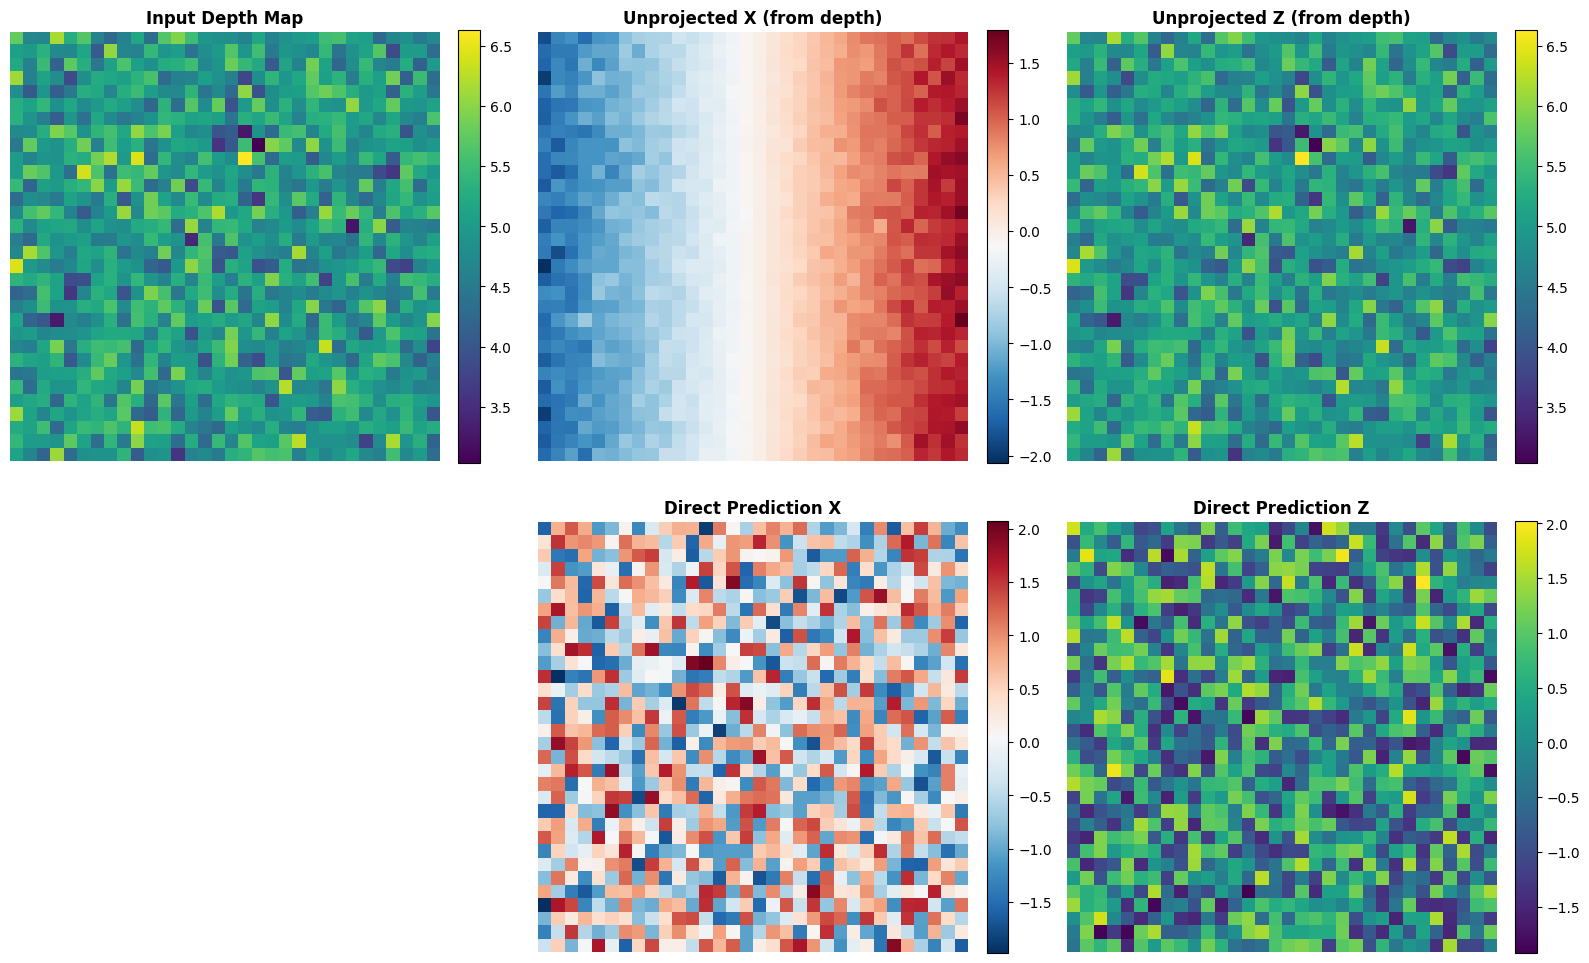


深度反投影的优势:
  ✓ 保证点在有效的相机射线上
  ✓ 利用已知的相机几何约束
  ✓ 深度是相对量,更容易学习
  ✓ 避免了3D位置的歧义性

实践中, VGGT主要使用深度反投影,而不是直接点预测。


In [6]:
# 深度反投影到3D点云 - Depth Unprojection to 3D Points

def unproject_depth_map_to_point_map(depth_map, intrinsics):
    """
    将深度图反投影为3D点图
    
    Args:
        depth_map: [B, 1, H, W] - 深度图
        intrinsics: [B, 4] - 相机内参 (fx, fy, cx, cy)
    Returns:
        point_map: [B, 3, H, W] - 3D点图 (x, y, z)
    """
    B, _, H, W = depth_map.shape
    
    # 创建像素坐标网格
    u = torch.arange(W, dtype=torch.float32).view(1, 1, 1, W).expand(B, 1, H, W)
    v = torch.arange(H, dtype=torch.float32).view(1, 1, H, 1).expand(B, 1, H, W)
    
    # 提取内参
    fx = intrinsics[:, 0].view(B, 1, 1, 1)
    fy = intrinsics[:, 1].view(B, 1, 1, 1)
    cx = intrinsics[:, 2].view(B, 1, 1, 1)
    cy = intrinsics[:, 3].view(B, 1, 1, 1)
    
    # 反投影公式
    x = (u - cx) * depth_map / fx
    y = (v - cy) * depth_map / fy
    z = depth_map
    
    # 拼接为3D点
    point_map = torch.cat([x, y, z], dim=1)  # [B, 3, H, W]
    
    return point_map


def inv_log(x):
    """inv_log激活函数,用于Point Head"""
    return torch.sign(x) * torch.log(1.0 + torch.abs(x))


# 演示深度反投影 vs 直接点预测
print("=" * 60)
print("深度反投影 vs 直接3D点预测")
print("=" * 60)

# 创建模拟数据
B, H, W = 2, 32, 32

# 模拟深度图 (平面 + 噪声)
depth_map = torch.ones(B, 1, H, W) * 5.0 + torch.randn(B, 1, H, W) * 0.5
depth_map = torch.clamp(depth_map, min=0.1)  # 确保正值

# 模拟相机内参 (fx, fy, cx, cy)
intrinsics = torch.tensor([
    [50.0, 50.0, W/2, H/2],  # Camera 1
    [50.0, 50.0, W/2, H/2],  # Camera 2
])

# 方法1: 深度反投影
point_map_unprojected = unproject_depth_map_to_point_map(depth_map, intrinsics)

# 方法2: 直接点预测 (模拟)
# 在实践中,这会来自Point Head的输出
point_map_direct = torch.randn(B, 3, H, W) * 2.0  # 随机预测
point_map_direct = inv_log(point_map_direct)  # 应用inv_log激活

print(f"\n深度图形状: {depth_map.shape}")
print(f"内参形状: {intrinsics.shape}")
print(f"反投影点图形状: {point_map_unprojected.shape}")
print(f"直接预测点图形状: {point_map_direct.shape}")

# 数值比较
print("\n方法1: 深度反投影")
print(f"  X范围: [{point_map_unprojected[:, 0].min():.3f}, {point_map_unprojected[:, 0].max():.3f}]")
print(f"  Y范围: [{point_map_unprojected[:, 1].min():.3f}, {point_map_unprojected[:, 1].max():.3f}]")
print(f"  Z范围: [{point_map_unprojected[:, 2].min():.3f}, {point_map_unprojected[:, 2].max():.3f}]")

print("\n方法2: 直接点预测 (with inv_log)")
print(f"  X范围: [{point_map_direct[:, 0].min():.3f}, {point_map_direct[:, 0].max():.3f}]")
print(f"  Y范围: [{point_map_direct[:, 1].min():.3f}, {point_map_direct[:, 1].max():.3f}]")
print(f"  Z范围: [{point_map_direct[:, 2].min():.3f}, {point_map_direct[:, 2].max():.3f}]")

# 可视化比较
fig = plt.figure(figsize=(16, 10))

# 显示第一个batch的结果
b = 0

# 原始深度图
ax1 = plt.subplot(2, 3, 1)
im1 = ax1.imshow(depth_map[b, 0].numpy(), cmap='viridis')
ax1.set_title('Input Depth Map', fontsize=12, fontweight='bold')
ax1.axis('off')
plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

# 反投影点云 - X坐标
ax2 = plt.subplot(2, 3, 2)
im2 = ax2.imshow(point_map_unprojected[b, 0].numpy(), cmap='RdBu_r')
ax2.set_title('Unprojected X (from depth)', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

# 反投影点云 - Z坐标
ax3 = plt.subplot(2, 3, 3)
im3 = ax3.imshow(point_map_unprojected[b, 2].numpy(), cmap='viridis')
ax3.set_title('Unprojected Z (from depth)', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

# 直接预测点云 - X坐标
ax4 = plt.subplot(2, 3, 5)
im4 = ax4.imshow(point_map_direct[b, 0].numpy(), cmap='RdBu_r')
ax4.set_title('Direct Prediction X', fontsize=12, fontweight='bold')
ax4.axis('off')
plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)

# 直接预测点云 - Z坐标
ax5 = plt.subplot(2, 3, 6)
im5 = ax5.imshow(point_map_direct[b, 2].numpy(), cmap='viridis')
ax5.set_title('Direct Prediction Z', fontsize=12, fontweight='bold')
ax5.axis('off')
plt.colorbar(im5, ax=ax5, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("\n深度反投影的优势:")
print("  ✓ 保证点在有效的相机射线上")
print("  ✓ 利用已知的相机几何约束")
print("  ✓ 深度是相对量,更容易学习")
print("  ✓ 避免了3D位置的歧义性")
print("\n实践中, VGGT主要使用深度反投影,而不是直接点预测。")

## Section 6: Track Head (CoTracker-based)

The Track Head is responsible for **2D point tracking** across video frames, based on [CoTracker (Karaev et al., 2023)](https://arxiv.org/abs/2307.07635).

### Architecture Overview

```
Image Tokens → DPT Feature Extractor (128-dim) → CoTracker Tracker → Tracks
```

### Two-Stage Design

1. **Feature Extraction** (DPT-based)
   - Input: Multi-scale image tokens
   - Output: Dense 128-dim feature maps `[B, S, 128, H, W]`

2. **Tracking** (CoTracker-based)
   - Input: Feature maps + query points
   - Output: 2D tracks, visibility, confidence

### Query-based Tracking

CoTracker uses a **query-based** approach:
- Each query point `(u, v, t)` specifies a pixel to track from frame t
- The tracker predicts the location of this point in all frames
- Queries can be:
  - **Grid-based**: Uniform grid of points
  - **User-specified**: Points of interest
  - **Adaptive**: Selected based on saliency

### Tracking Module (4 iterations)

For each iteration:
1. **Correlation**: Compute similarity between query features and all frame features
2. **Aggregation**: Pool correlation features
3. **Update**: GRU updates track state
4. **Refinement**: Predict position delta

```python
for iteration in range(4):
    corr = compute_correlation(query_feat, frame_feats)
    context = aggregate(corr)
    hidden = gru(context, hidden)
    delta = predict_delta(hidden)
    track = track + delta
```

### Output Format

- **Tracks**: `[B, S, N_q, 2]` - (u, v) coordinates for N_q queries across S frames
- **Visibility**: `[B, S, N_q, 1]` - binary visibility (0 = occluded, 1 = visible)
- **Confidence**: `[B, S, N_q, 1]` - tracking confidence [0, 1]

演示基于CoTracker的点跟踪

特征图形状: torch.Size([1, 8, 128, 64, 64])
查询点形状: torch.Size([1, 5, 3])
查询点数量: 5
视频帧数: 8

跟踪输出形状: torch.Size([4, 1, 8, 5, 2])
  - 4次迭代, 每次输出 [B=1, S=8, N_q=5, 2]


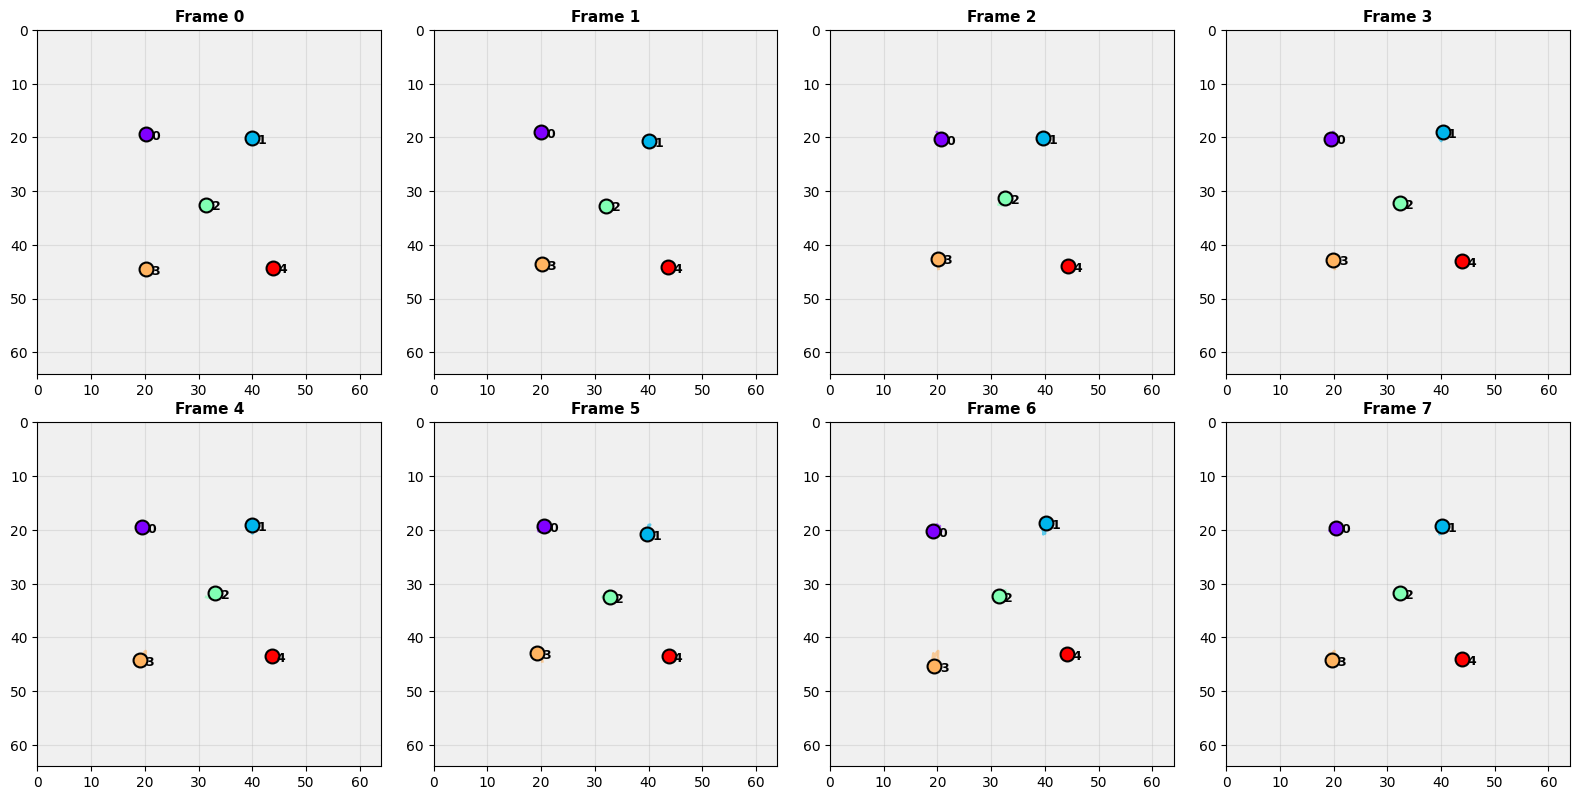

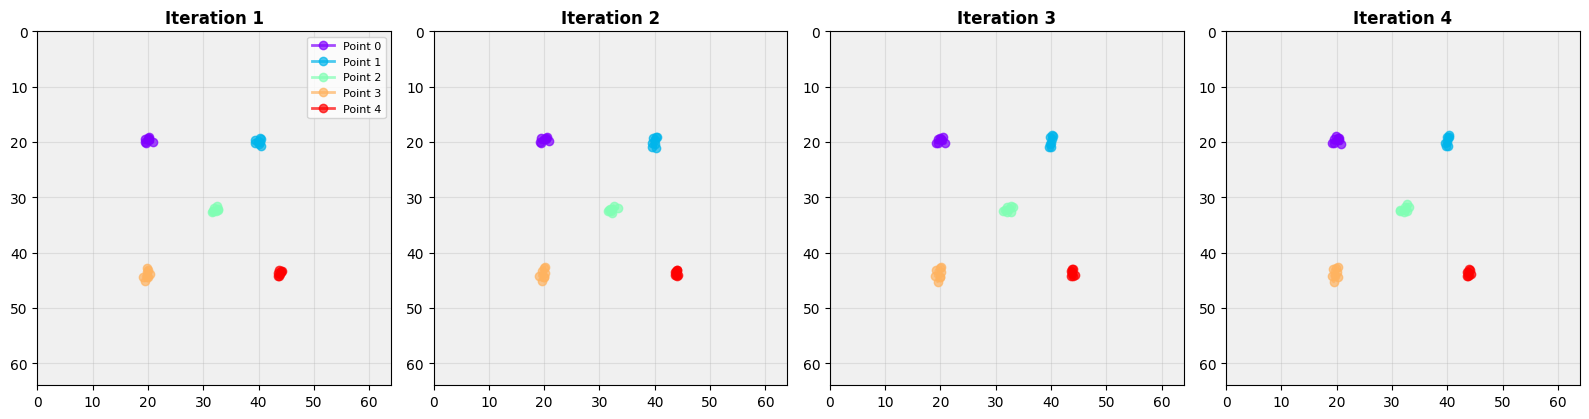


Track Head的关键特性:
  1. 查询驱动: 用户或系统指定要跟踪的点
  2. 特征匹配: 在特征空间中搜索对应点
  3. 迭代优化: 逐步优化跟踪位置
  4. 遮挡处理: 输出可见性和置信度
  5. 时序建模: GRU建模轨迹的时间连贯性


In [7]:
# 简化的跟踪概念演示 - Simplified Tracking Concept

def simplified_tracking(feature_maps, query_points, num_iterations=4):
    """
    简化的点跟踪演示
    
    Args:
        feature_maps: [B, S, C, H, W] - 特征图序列
        query_points: [B, N_q, 3] - 查询点 (u, v, t)
        num_iterations: int - 迭代次数
    Returns:
        tracks: [num_iterations, B, S, N_q, 2] - 跟踪轨迹
    """
    B, S, C, H, W = feature_maps.shape
    N_q = query_points.shape[1]
    
    # 初始化轨迹为查询点位置
    tracks = query_points[:, :, :2].unsqueeze(1).expand(B, S, N_q, 2).clone()  # [B, S, N_q, 2]
    all_tracks = []
    
    # 迭代优化
    for iter_idx in range(num_iterations):
        # 模拟: 在特征空间中搜索最佳匹配
        # 实际实现会使用correlation + GRU
        
        # 添加小的随机偏移 (模拟跟踪更新)
        noise = torch.randn_like(tracks) * 0.5 / (iter_idx + 1)  # 噪声逐渐减小
        tracks = tracks + noise
        
        # 限制在图像边界内
        tracks[..., 0] = torch.clamp(tracks[..., 0], 0, W - 1)
        tracks[..., 1] = torch.clamp(tracks[..., 1], 0, H - 1)
        
        all_tracks.append(tracks.clone())
    
    return torch.stack(all_tracks, dim=0)  # [num_iterations, B, S, N_q, 2]


# 演示跟踪
print("=" * 60)
print("演示基于CoTracker的点跟踪")
print("=" * 60)

# 创建模拟数据
B, S = 1, 8  # 1个batch, 8帧
C, H, W = 128, 64, 64
N_q = 5  # 5个查询点

# 模拟特征图
feature_maps = torch.randn(B, S, C, H, W)

# 定义查询点 (在第0帧的位置)
query_points = torch.tensor([
    [[20.0, 20.0, 0],  # 左上
     [40.0, 20.0, 0],  # 右上
     [32.0, 32.0, 0],  # 中心
     [20.0, 44.0, 0],  # 左下
     [44.0, 44.0, 0]]  # 右下
])

print(f"\n特征图形状: {feature_maps.shape}")
print(f"查询点形状: {query_points.shape}")
print(f"查询点数量: {N_q}")
print(f"视频帧数: {S}")

# 运行跟踪
tracks = simplified_tracking(feature_maps, query_points, num_iterations=4)
print(f"\n跟踪输出形状: {tracks.shape}")
print(f"  - 4次迭代, 每次输出 [B={B}, S={S}, N_q={N_q}, 2]")

# 可视化跟踪轨迹
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# 为每帧绘制轨迹
colors = plt.cm.rainbow(np.linspace(0, 1, N_q))

for frame_idx in range(S):
    ax = axes[frame_idx]
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)  # 反转Y轴以匹配图像坐标
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Frame {frame_idx}', fontsize=11, fontweight='bold')
    
    # 绘制背景网格
    ax.set_facecolor('#f0f0f0')
    
    # 绘制每个查询点的轨迹
    for q_idx in range(N_q):
        # 获取从第0帧到当前帧的轨迹 (使用最后一次迭代的结果)
        traj = tracks[-1, 0, :frame_idx+1, q_idx, :].numpy()  # [frame_idx+1, 2]
        
        if frame_idx > 0:
            # 绘制轨迹线
            ax.plot(traj[:, 0], traj[:, 1], '-', color=colors[q_idx], 
                   linewidth=2, alpha=0.6)
        
        # 绘制当前点
        ax.plot(traj[-1, 0], traj[-1, 1], 'o', color=colors[q_idx], 
               markersize=10, markeredgecolor='black', markeredgewidth=1.5)
        
        # 标注点编号
        ax.text(traj[-1, 0] + 1, traj[-1, 1] + 1, f'{q_idx}', 
               fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# 可视化迭代优化效果
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for iter_idx in range(4):
    ax = axes[iter_idx]
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
    ax.set_title(f'Iteration {iter_idx + 1}', fontsize=12, fontweight='bold')
    ax.set_facecolor('#f0f0f0')
    
    # 绘制所有帧的所有轨迹
    for q_idx in range(N_q):
        traj = tracks[iter_idx, 0, :, q_idx, :].numpy()  # [S, 2]
        ax.plot(traj[:, 0], traj[:, 1], 'o-', color=colors[q_idx], 
               linewidth=2, markersize=6, alpha=0.7, label=f'Point {q_idx}')
    
    if iter_idx == 0:
        ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

print("\nTrack Head的关键特性:")
print("  1. 查询驱动: 用户或系统指定要跟踪的点")
print("  2. 特征匹配: 在特征空间中搜索对应点")
print("  3. 迭代优化: 逐步优化跟踪位置")
print("  4. 遮挡处理: 输出可见性和置信度")
print("  5. 时序建模: GRU建模轨迹的时间连贯性")

## Section 7: Multi-task Head Comparison

Let's compare all four output heads across different dimensions:

### Comparison Table

| Aspect | Camera Head | Depth Head | Point Head | Track Head |
|--------|-------------|------------|------------|------------|
| **Input** | Camera tokens [B,S,C] | Multi-scale tokens | Multi-scale tokens | Feature maps [B,S,128,H,W] |
| **Architecture** | 4-layer Transformer | DPT | DPT | DPT + CoTracker |
| **Output Shape** | [B,S,9] | [B,S,H,W] | [B,S,H,W,3] | [B,S,N_q,2] |
| **Output Type** | Pose + intrinsics | Dense depth | Dense 3D points | Sparse 2D tracks |
| **Activation** | None (linear) | exp, expp1 | inv_log | None |
| **Iterations** | 4 (refinement) | 1 | 1 | 4 (tracking) |
| **Resolution** | Per-frame | Per-pixel | Per-pixel | Per-query |
| **Primary Use** | Camera localization | 3D reconstruction | Direct 3D (rare) | Correspondence |
| **Key Feature** | Iterative refinement | Multi-scale fusion | World coords | Query-based |

### Design Patterns

1. **Shared Backbone**: All heads use the same DINOv2 encoder + aggregator
2. **Specialized Architectures**: Each head has task-specific design
3. **Multi-scale Processing**: Dense prediction heads (Depth, Point, Track) use DPT
4. **Iterative Refinement**: Camera and Track heads use multiple iterations
5. **Task-specific Activations**: Different activations for different output spaces

                              VGGT Multi-task Heads Comparison
Aspect               | Camera Head               | Depth Head                | Point Head                   | Track Head                    
--------------------------------------------------------------------------------------------------------------------------------------------
Input                | Camera tokens [B,S,C]     | Multi-scale tokens        | Multi-scale tokens           | Feature maps [B,S,128,H,W]    
Architecture         | 4-layer Transformer       | DPT                       | DPT                          | DPT + CoTracker               
Output Shape         | [B,S,9]                   | [B,S,H,W]                 | [B,S,H,W,3]                  | [B,S,N_q,2]                   
Output Type          | Pose + intrinsics         | Dense depth               | Dense 3D points              | Sparse 2D tracks              
Activation           | None (linear)             | exp, expp1                | inv_log     

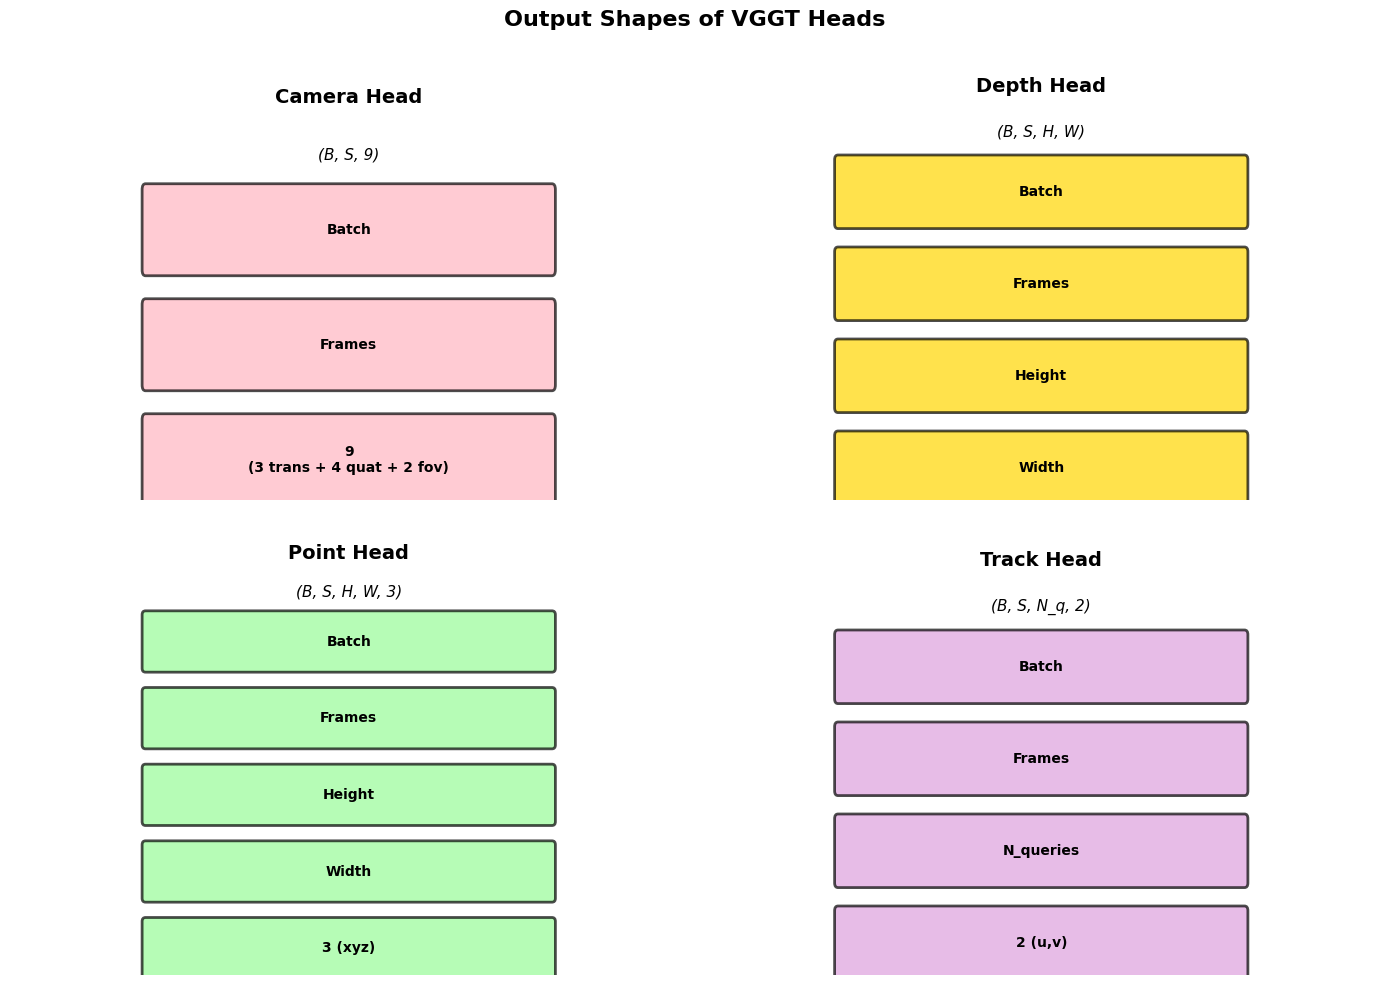


关键设计模式:
  1. 共享主干 (Shared Backbone): 所有头共享DINOv2编码器和聚合器
  2. 专用架构 (Specialized Architectures): 每个头针对特定任务设计
  3. 多尺度处理 (Multi-scale Processing): 稠密预测头使用DPT
  4. 迭代优化 (Iterative Refinement): Camera和Track头使用多次迭代
  5. 任务特定激活 (Task-specific Activations): 不同输出空间使用不同激活函数


In [8]:
# 打印详细对比表 - Detailed Comparison Table

print("="*100)
print(" " * 30 + "VGGT Multi-task Heads Comparison")
print("="*100)

# 定义对比数据
comparison_data = {
    'Aspect': [
        'Input',
        'Architecture',
        'Output Shape',
        'Output Type',
        'Activation',
        'Iterations',
        'Resolution',
        'Primary Use',
        'Key Feature'
    ],
    'Camera Head': [
        'Camera tokens [B,S,C]',
        '4-layer Transformer',
        '[B,S,9]',
        'Pose + intrinsics',
        'None (linear)',
        '4 (refinement)',
        'Per-frame',
        'Camera localization',
        'Iterative refinement'
    ],
    'Depth Head': [
        'Multi-scale tokens',
        'DPT',
        '[B,S,H,W]',
        'Dense depth',
        'exp, expp1',
        '1',
        'Per-pixel',
        '3D reconstruction',
        'Multi-scale fusion'
    ],
    'Point Head': [
        'Multi-scale tokens',
        'DPT',
        '[B,S,H,W,3]',
        'Dense 3D points',
        'inv_log',
        '1',
        'Per-pixel',
        'Direct 3D (rare)',
        'World coords'
    ],
    'Track Head': [
        'Feature maps [B,S,128,H,W]',
        'DPT + CoTracker',
        '[B,S,N_q,2]',
        'Sparse 2D tracks',
        'None',
        '4 (tracking)',
        'Per-query',
        'Correspondence',
        'Query-based'
    ]
}

# 打印表格
col_widths = [20, 25, 25, 28, 30]

# 打印表头
header = f"{'Aspect':<{col_widths[0]}} | {'Camera Head':<{col_widths[1]}} | {'Depth Head':<{col_widths[2]}} | {'Point Head':<{col_widths[3]}} | {'Track Head':<{col_widths[4]}}"
print(header)
print("-" * len(header))

# 打印每一行
for i, aspect in enumerate(comparison_data['Aspect']):
    row = f"{aspect:<{col_widths[0]}} | {comparison_data['Camera Head'][i]:<{col_widths[1]}} | {comparison_data['Depth Head'][i]:<{col_widths[2]}} | {comparison_data['Point Head'][i]:<{col_widths[3]}} | {comparison_data['Track Head'][i]:<{col_widths[4]}}"
    print(row)

print("="*100)

# 可视化输出形状
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

heads_info = [
    {'name': 'Camera Head', 'shape': '(B, S, 9)', 'color': '#FFB6C1', 
     'dims': ['Batch', 'Frames', '9\n(3 trans + 4 quat + 2 fov)']},
    {'name': 'Depth Head', 'shape': '(B, S, H, W)', 'color': '#FFD700',
     'dims': ['Batch', 'Frames', 'Height', 'Width']},
    {'name': 'Point Head', 'shape': '(B, S, H, W, 3)', 'color': '#98FB98',
     'dims': ['Batch', 'Frames', 'Height', 'Width', '3 (xyz)']},
    {'name': 'Track Head', 'shape': '(B, S, N_q, 2)', 'color': '#DDA0DD',
     'dims': ['Batch', 'Frames', 'N_queries', '2 (u,v)']},
]

for idx, head in enumerate(heads_info):
    ax = axes[idx]
    ax.set_xlim(0, 10)
    ax.set_ylim(0, len(head['dims']) + 1)
    ax.axis('off')
    
    # 标题
    ax.text(5, len(head['dims']) + 0.5, head['name'], 
           ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(5, len(head['dims']), head['shape'], 
           ha='center', va='center', fontsize=11, style='italic')
    
    # 绘制维度框
    for i, dim in enumerate(head['dims']):
        y_pos = len(head['dims']) - i - 1
        
        # 框
        rect = FancyBboxPatch((2, y_pos), 6, 0.7, 
                             boxstyle="round,pad=0.05",
                             edgecolor='black', 
                             facecolor=head['color'],
                             alpha=0.7,
                             linewidth=2)
        ax.add_patch(rect)
        
        # 文本
        ax.text(5, y_pos + 0.35, dim, ha='center', va='center', 
               fontsize=10, fontweight='bold')

plt.suptitle('Output Shapes of VGGT Heads', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("\n关键设计模式:")
print("  1. 共享主干 (Shared Backbone): 所有头共享DINOv2编码器和聚合器")
print("  2. 专用架构 (Specialized Architectures): 每个头针对特定任务设计")
print("  3. 多尺度处理 (Multi-scale Processing): 稠密预测头使用DPT")
print("  4. 迭代优化 (Iterative Refinement): Camera和Track头使用多次迭代")
print("  5. 任务特定激活 (Task-specific Activations): 不同输出空间使用不同激活函数")

## Summary

```
╔═══════════════════════════════════════════════════════════════════════╗
║                    Key Takeaways - Multi-task Heads                   ║
╠═══════════════════════════════════════════════════════════════════════╣
║                                                                       ║
║  1. VGGT uses 4 specialized output heads:                            ║
║     • Camera Head: Pose estimation with iterative refinement         ║
║     • Depth Head: Dense depth prediction using DPT                   ║
║     • Point Head: Direct 3D point prediction (rarely used)           ║
║     • Track Head: 2D point tracking with CoTracker                   ║
║                                                                       ║
║  2. Camera Head uses quaternions for rotation representation:        ║
║     • Compact (4 params) and continuous                              ║
║     • No gimbal lock, easy to normalize                              ║
║     • Preferred over Euler angles and rotation matrices              ║
║                                                                       ║
║  3. DPT architecture enables dense prediction:                       ║
║     • Multi-scale features from layers [4, 11, 17, 23]               ║
║     • Reassemble tokens → 2D feature maps                            ║
║     • Hierarchical fusion from coarse to fine                        ║
║                                                                       ║
║  4. Depth unprojection is preferred over direct point prediction:    ║
║     • Leverages camera geometry constraints                          ║
║     • Relative depth is easier to learn than absolute 3D positions   ║
║     • Ensures points lie on valid camera rays                        ║
║                                                                       ║
║  5. Track Head uses query-based tracking:                            ║
║     • User or system specifies points to track                       ║
║     • Correlation + GRU for temporal coherence                       ║
║     • Outputs tracks, visibility, and confidence                     ║
║                                                                       ║
║  6. Multi-task learning design patterns:                             ║
║     • Shared backbone for efficiency                                 ║
║     • Specialized heads for task-specific inductive biases           ║
║     • Task-specific activations for different output spaces          ║
║                                                                       ║
╚═══════════════════════════════════════════════════════════════════════╝
```

## What's Next?

In the next notebook, we'll dive deeper into:

**Phase 5, Notebook 03: Architecture Deep Dive**
- Complete VGGT model architecture
- Training strategies and loss functions
- Inference pipeline
- Performance analysis

Continue to [03_architecture_deep_dive.ipynb](./03_architecture_deep_dive.ipynb)

---

## References

1. **VGGT**: [Video Gaussian Gaussian Transformer](https://arxiv.org/abs/TODO)
2. **DPT**: Ranftl et al., "Vision Transformers for Dense Prediction", ICCV 2021
3. **CoTracker**: Karaev et al., "CoTracker: It is Better to Track Together", 2023
4. **Quaternions**: Shoemake, "Animating rotation with quaternion curves", SIGGRAPH 1985
5. **DINOv2**: Oquab et al., "DINOv2: Learning Robust Visual Features without Supervision", 2023